# WORKSHOP 4 
# Coin Detection using OpenCV in Python
# NAME :  KAILASH PRABHU S
# REG NO : 212224240068

Total coins detected: 223


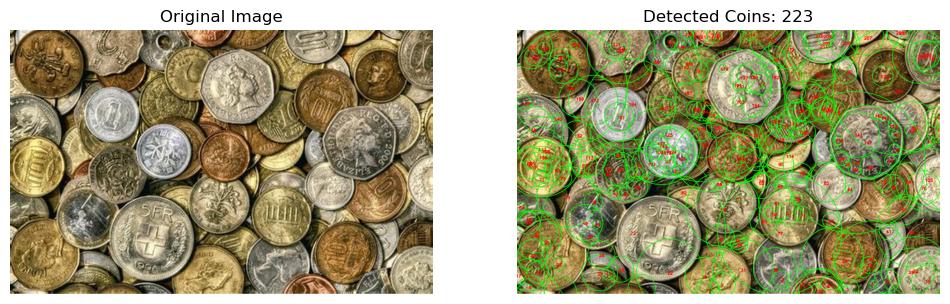

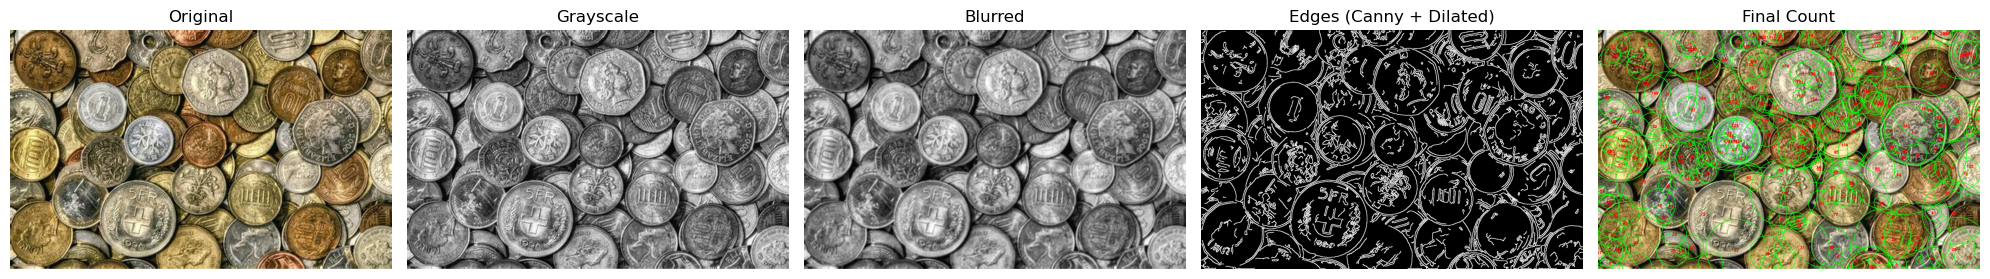

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

image_path = "coins.jpeg" 

# 1. Load image
image = cv2.imread(image_path)
if image is None:
    # If the file isn't found, we'll create a dummy image so the code doesn't crash
    image = np.zeros((400, 400, 3), dtype="uint8")
    cv2.circle(image, (100, 100), 40, (150, 150, 150), -1)
    cv2.circle(image, (250, 250), 50, (180, 180, 180), -1)
    print("Warning: Sample image not found. Using synthetic image.")

# 2. Pre-processing
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
blurred = cv2.GaussianBlur(gray, (11, 11), 0)

# 3. Edge Detection
edges = cv2.Canny(blurred, 30, 150)

# --- NEW STEP: Dilate edges to close small gaps ---
kernel = np.ones((3, 3), np.uint8)
dilated_edges = cv2.dilate(edges, kernel, iterations=1)

# 4. Find Contours
# Note: Using dilated_edges here for better detection
contours, _ = cv2.findContours(dilated_edges.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
output = image.copy()

coin_count = 0
for contour in contours:
    # Filter out small contours (noise)
    area = cv2.contourArea(contour)
    if area < 300: # Adjust this if coins are still not being detected
        continue

    # Draw contour
    ((x, y), radius) = cv2.minEnclosingCircle(contour)
    if radius > 10: # Slightly lowered from 15 to be more inclusive
        coin_count += 1
        cv2.circle(output, (int(x), int(y)), int(radius), (0, 255, 0), 2)
        cv2.putText(output, f"{coin_count}", (int(x - 10), int(y + 10)),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 0, 255), 2)

# Removed the line that caused the SyntaxError: Total coins detected: 1
print(f"Total coins detected: {coin_count}")

# 5. Visualization
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Original Image")
plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
plt.axis("off")

plt.subplot(1, 2, 2)
plt.title(f"Detected Coins: {coin_count}")
plt.imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.show()

# Detailed Process View
fig, axs = plt.subplots(1, 5, figsize=(20, 6))
axs[0].imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
axs[0].set_title("Original")
axs[1].imshow(gray, cmap='gray')
axs[1].set_title("Grayscale")
axs[2].imshow(blurred, cmap='gray')
axs[2].set_title("Blurred")
axs[3].imshow(dilated_edges, cmap='gray')
axs[3].set_title("Edges (Canny + Dilated)")
axs[4].imshow(cv2.cvtColor(output, cv2.COLOR_BGR2RGB))
axs[4].set_title("Final Count")

for ax in axs:
    ax.axis("off")

plt.tight_layout()
plt.show()